# Reusable Template — Tabular EDA / Trend-Analysis Project
### Generic skeleton for "load a CSV → clean it → group it → visualize trends → summarize findings" projects

This notebook is deliberately **dataset-agnostic**. Edit the `# CONFIG` cell at the top, then work
down the notebook — every section is written to work unchanged for most flat tabular datasets
(fuel economy, retail sales, sports stats, survey data, sensor logs, etc.). Delete/adapt sections that
don't apply to your dataset.


## 0. Configuration — edit this cell for your project

In [1]:
# ---------------------------------------------------------------
# CONFIG: fill these in for your dataset, then run the whole notebook
# ---------------------------------------------------------------
DATA_PATH = "vehicles.csv"          # path to your CSV
TIME_COL = "year"                   # the column you'll analyze trends over (year, date, quarter, ...)
CATEGORY_COL = "make"               # a categorical column you'll segment/facet by
NUMERIC_COLS = ["comb08", "city08", "highway08", "displ"]   # numeric columns of interest
TARGET_COL = "comb08"               # the main outcome/metric you care about
# ---------------------------------------------------------------


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 100)


## 1. Load & inventory
Generic first look at any new dataset.

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()


shape: (50242, 84)
columns: ['barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08', 'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2', 'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U', 'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders', 'displ', 'drive', 'engId', 'eng_dscr', 'feScore', 'fuelCost08', 'fuelCostA08', 'fuelType', 'fuelType1', 'ghgScore', 'ghgScoreA', 'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE', 'highwayUF', 'hlv', 'hpv', 'id', 'lv2', 'lv4', 'make', 'model', 'mpgData', 'phevBlended', 'pv2', 'pv4', 'range', 'rangeCity', 'rangeCityA', 'rangeHwy', 'rangeHwyA', 'trany', 'UCity', 'UCityA', 'UHighway', 'UHighwayA', 'VClass', 'year', 'youSaveSpend', 'baseModel', 'guzzler', 'trans_dscr', 'tCharger', 'sCharger', 'atvType', 'fuelType2', 'rangeA', 'evMotor', 'mfrCode', 'c240Dscr', 'charge240b', 'c240bDscr', 'createdOn', 'modifiedOn', 'startStop', 'phevCity', 'phevHwy', 'phevComb']


,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,comb08U,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,drive,engId,eng_dscr,feScore,fuelCost08,fuelCostA08,fuelType,fuelType1,ghgScore,ghgScoreA,highway08,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,id,lv2,lv4,make,model,mpgData,phevBlended,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,trany,UCity,UCityA,UHighway,UHighwayA,VClass,year,youSaveSpend,baseModel,guzzler,trans_dscr,tCharger,sCharger,atvType,fuelType2,rangeA,evMotor,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,14.167143,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,423.190476,21,0.0,0,0.0,0.0,0.0,0.0,4.0,2.0,Rear-Wheel Drive,9011,(FFS),-1,2950,0,Regular,Regular Gasoline,-1,-1,25,0.0,0,0.0,0.0,0.0,0.0,0,0,1,0,0,Alfa Romeo,Spider Veloce 2000,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,23.3333,0.0,35.0000,0.0,Two Seaters,1985,-3750,Spider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,27.046364,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,12.0,4.9,Rear-Wheel Drive,22020,(GUZZLER),-1,5600,0,Regular,Regular Gasoline,-1,-1,14,0.0,0,0.0,0.0,0.0,0.0,0,0,10,0,0,Ferrari,Testarossa,N,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,11.0000,0.0,19.0000,0.0,Two Seaters,1985,-17000,Testarossa,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,11.018889,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,329.148148,27,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,Front-Wheel Drive,2100,(FFS),-1,2300,0,Regular,Regular Gasoline,-1,-1,33,0.0,0,0.0,0.0,0.0,0.0,19,77,100,0,0,Dodge,Charger,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,29.0000,0.0,47.0000,0.0,Subcompact Cars,1985,-500,Charger,NaN,SIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,27.046364,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,8.0,5.2,Rear-Wheel Drive,2850,NaN,-1,5600,0,Regular,Regular Gasoline,-1,-1,12,0.0,0,0.0,0.0,0.0,0.0,0,0,1000,0,0,Dodge,B150/B250 Wagon 2WD,N,False,0,0,0,0.0,0.0,0.0,0.0,Automatic 3-spd,12.2222,0.0,16.6667,0.0,Vans,1985,-17000,B150/B250 Wagon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,15.658421,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,467.736842,19,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,4-Wheel or All-Wheel Drive,66031,"(FFS,TRBO)",-1,4000,0,Premium,Premium Gasoline,-1,-1,23,0.0,0,0.0,0.0,0.0,0.0,0,0,10000,0,14,Subaru,Legacy AWD Turbo,N,False,0,90,0,0.0,0.0,0.0,0.0,Manual 5-spd,21.0000,0.0,32.0000,0.0,Compact Cars,1993,-9000,Legacy/Outback,NaN,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0


In [4]:
df.dtypes


barrels08     float64
barrelsA08    float64
charge120     float64
charge240     float64
city08          int64
               ...   
modifiedOn        str
startStop         str
phevCity        int64
phevHwy         int64
phevComb        int64
Length: 84, dtype: object

In [5]:
# Null counts per column - triage what needs cleaning
df.isnull().sum().sort_values(ascending=False).head(20)


c240bDscr     50107
c240Dscr      50101
sCharger      49091
rangeA        48232
fuelType2     48229
guzzler       47384
evMotor       46642
atvType       43452
tCharger      38540
trans_dscr    35198
startStop     31689
mfrCode       30808
eng_dscr      18389
cylinders      1619
displ          1617
drive          1186
mpgData         247
trany            11
fuelType1         2
barrels08         0
dtype: int64

In [6]:
# Columns pandas silently loaded as 'object' that might actually be numeric/categorical worth checking
df.select_dtypes(include="object").nunique().sort_values(ascending=False).head(20)


/tmp/ipykernel_565/3838038727.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique().sort_values(ascending=False).head(20)


model         5665
baseModel     1501
eng_dscr       626
evMotor        614
createdOn      476
modifiedOn     328
rangeA         253
make           146
mfrCode         58
trans_dscr      52
trany           40
VClass          34
fuelType        16
atvType         10
drive            7
fuelType1        7
c240bDscr        7
c240Dscr         5
fuelType2        4
guzzler          3
dtype: int64

## 2. Clean
Generic NaN-safe casting + boolean-filter pattern. Adapt the specific rules to your domain.

In [7]:
def clean_numeric(frame: pd.DataFrame, col: str) -> pd.DataFrame:
    """Drop NaNs in `col` and cast it to float. Returns a copy."""
    out = frame[frame[col].notnull()].copy()
    out[col] = out[col].astype(float)
    return out

clean = df.copy()
for c in NUMERIC_COLS:
    if c in clean.columns:
        clean = clean_numeric(clean, c)

len(clean)


48625

In [8]:
# TEMPLATE: define whatever domain-specific inclusion/exclusion rules matter for your analysis.
# Example pattern (edit the conditions for your project):
# criteria1 = clean["some_col"].isin([...])
# criteria2 = clean["other_col"].isnull()
# clean = clean[criteria1 & criteria2]


## 3. Describe
Quick numeric + categorical summaries.

In [9]:
clean[NUMERIC_COLS].describe()


,comb08,city08,highway08,displ
count,48625.000000,48625.000000,48625.000000,48625.000000
mean,20.727506,18.457460,24.619003,3.262048
std,5.651284,5.508157,6.131816,1.348968
min,7.000000,6.000000,9.000000,0.000000
25%,17.000000,15.000000,20.000000,2.100000
50%,20.000000,18.000000,24.000000,3.000000
75%,24.000000,21.000000,28.000000,4.200000
max,112.000000,126.000000,99.000000,8.400000


In [10]:
clean[CATEGORY_COL].value_counts().head(15)


make
Chevrolet        4533
Ford             3878
GMC              2866
Dodge            2707
Toyota           2581
BMW              2552
Mercedes-Benz    2029
Nissan           1680
Porsche          1505
Volkswagen       1330
Audi             1298
Honda            1211
Jeep             1167
Mazda            1154
Mitsubishi       1145
Name: count, dtype: int64

## 4. Trend over time (split-apply-combine)

In [11]:
trend = clean.groupby(TIME_COL)[NUMERIC_COLS].mean().reset_index()
trend.head()


,year,comb08,city08,highway08,displ
0,1984,19.881874,17.982688,23.075356,3.165071
1,1985,19.804002,17.874044,23.037081,3.167863
2,1986,19.550413,17.665289,22.699174,3.183802
3,1987,19.228549,17.310345,22.445068,3.174018
4,1988,19.328319,17.333628,22.702655,3.194956


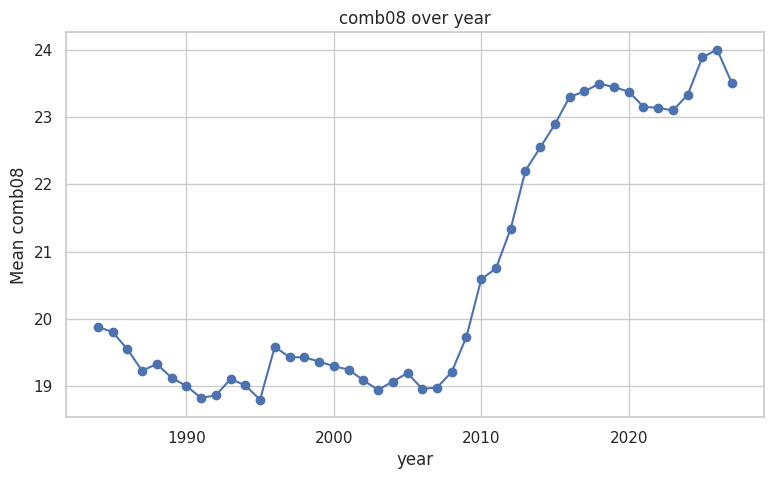

In [12]:
fig, ax = plt.subplots()
ax.plot(trend[TIME_COL], trend[TARGET_COL], marker="o")
ax.set_xlabel(TIME_COL); ax.set_ylabel(f"Mean {TARGET_COL}")
ax.set_title(f"{TARGET_COL} over {TIME_COL}")
plt.show()


## 5. Wide -> long reshape for multi-variable comparison plots

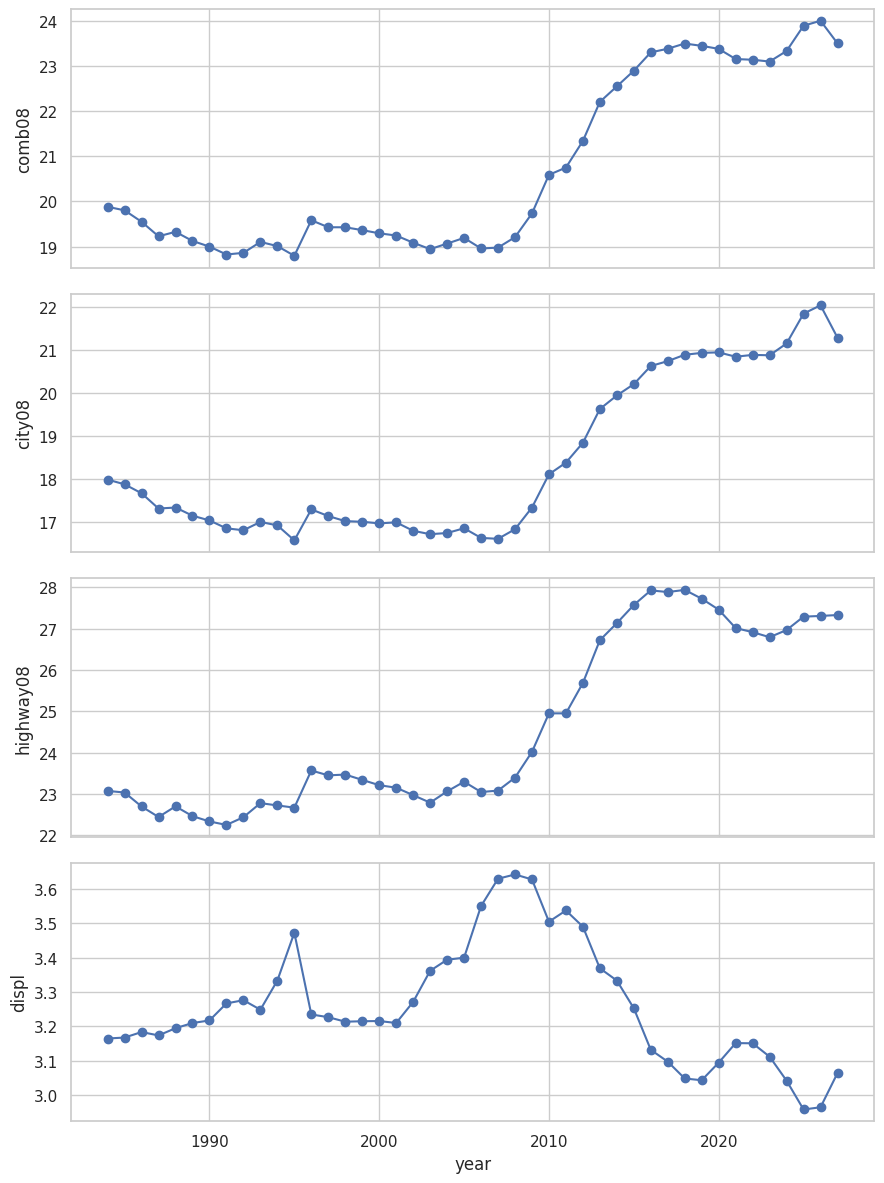

In [13]:
long = trend.melt(id_vars=TIME_COL, value_vars=NUMERIC_COLS,
                   var_name="variable", value_name="value")

fig, axes = plt.subplots(len(NUMERIC_COLS), 1, figsize=(9, 3 * len(NUMERIC_COLS)), sharex=True)
if len(NUMERIC_COLS) == 1:
    axes = [axes]
for ax, var in zip(axes, NUMERIC_COLS):
    sub = long[long["variable"] == var]
    ax.plot(sub[TIME_COL], sub["value"], marker="o")
    ax.set_ylabel(var)
axes[-1].set_xlabel(TIME_COL)
plt.tight_layout(); plt.show()


## 6. Segment by category (small multiples)

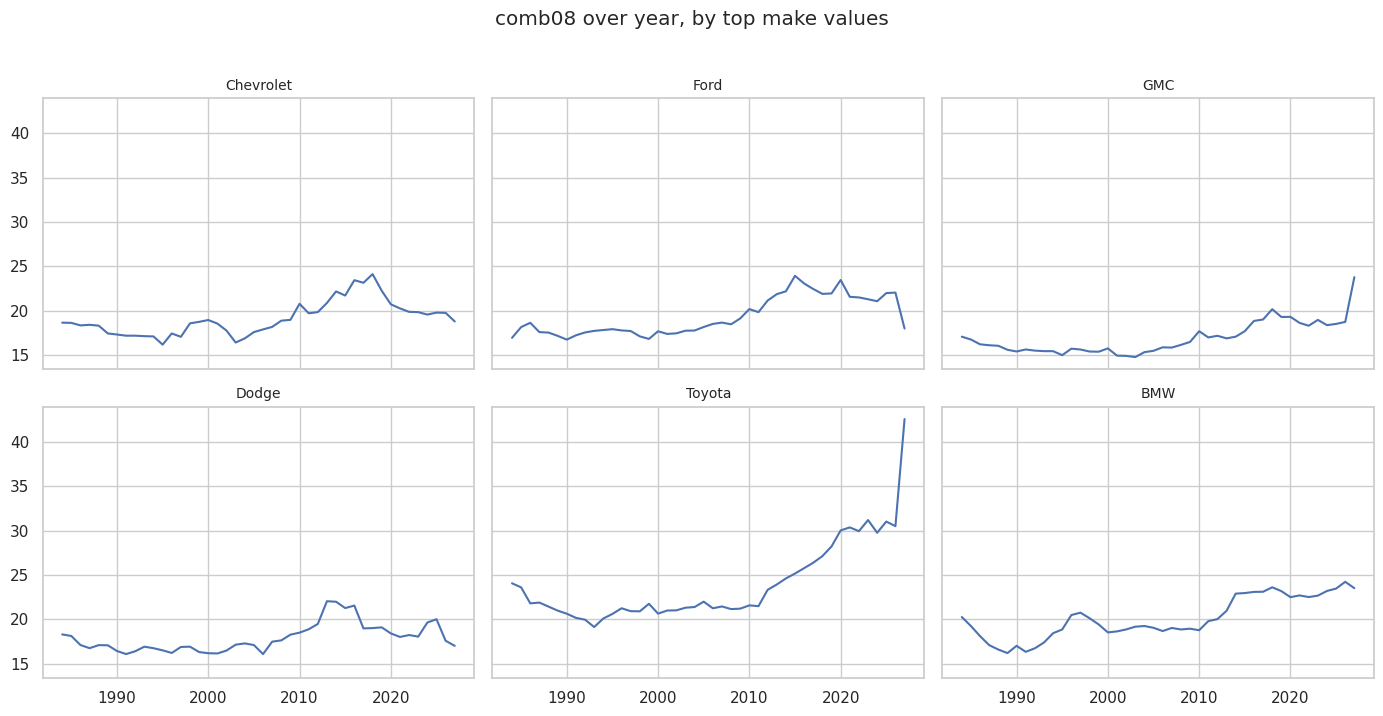

In [14]:
top_categories = clean[CATEGORY_COL].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()
for ax, cat in zip(axes, top_categories):
    sub = clean[clean[CATEGORY_COL] == cat].groupby(TIME_COL)[TARGET_COL].mean()
    ax.plot(sub.index, sub.values)
    ax.set_title(str(cat), fontsize=10)
for ax in axes[len(top_categories):]:
    ax.axis("off")
fig.suptitle(f"{TARGET_COL} over {TIME_COL}, by top {CATEGORY_COL} values", y=1.02)
plt.tight_layout(); plt.show()


## 7. Categories present across *every* time period

In [15]:
per_period_sets = [set(g[CATEGORY_COL].unique()) for _, g in clean.groupby(TIME_COL)]
always_present = reduce(set.intersection, per_period_sets)
print(f"{len(always_present)} '{CATEGORY_COL}' values present in every '{TIME_COL}'")
sorted(always_present)[:20]


18 'make' values present in every 'year'


['Audi',
 'BMW',
 'Buick',
 'Chevrolet',
 'Chrysler',
 'Dodge',
 'Ford',
 'GMC',
 'Honda',
 'Jeep',
 'Lincoln',
 'Mercedes-Benz',
 'Mitsubishi',
 'Nissan',
 'Subaru',
 'Toyota',
 'Volkswagen',
 'Volvo']

## 8. Relationships between numeric variables

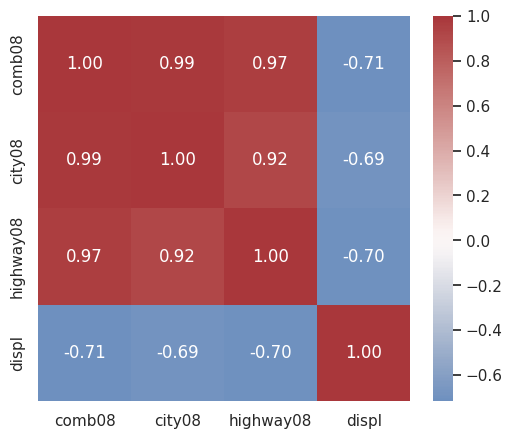

In [16]:
corr = clean[NUMERIC_COLS].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.show()


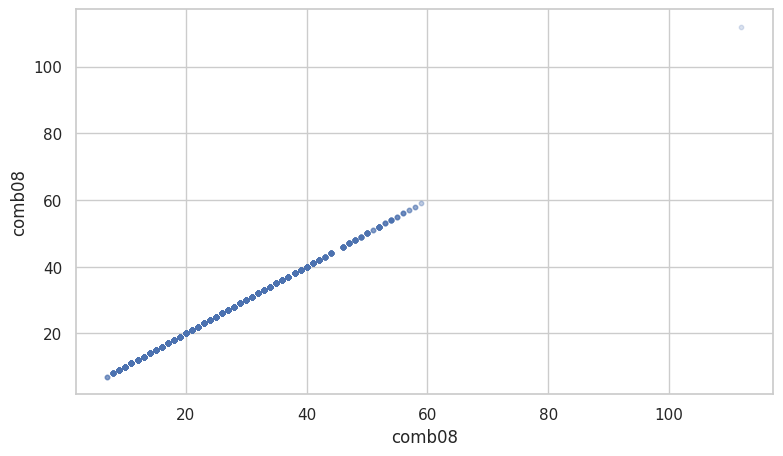

In [17]:
x_col, y_col = NUMERIC_COLS[0], TARGET_COL
fig, ax = plt.subplots()
ax.scatter(clean[x_col], clean[y_col], alpha=0.2, s=10)
ax.set_xlabel(x_col); ax.set_ylabel(y_col)
plt.show()


## 9. Distribution by category

/tmp/ipykernel_565/385293754.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


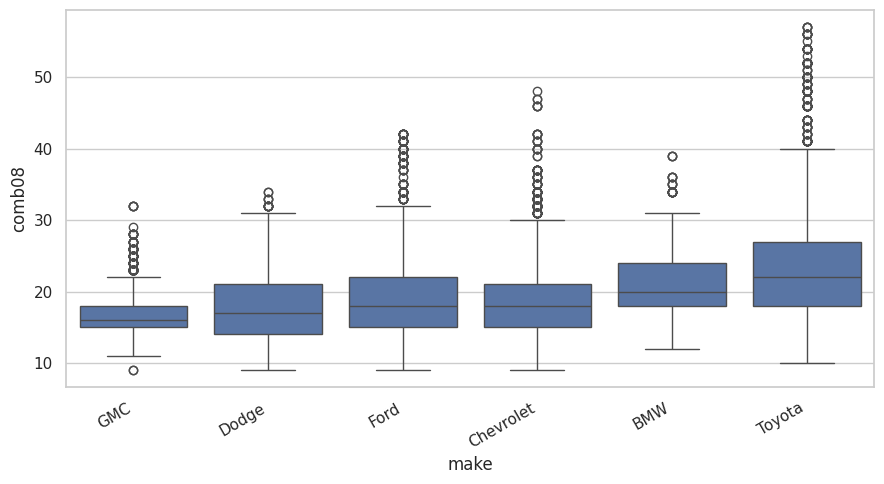

In [18]:
order = clean.groupby(CATEGORY_COL)[TARGET_COL].median().sort_values().index
top_n_order = [c for c in order if c in top_categories]

fig, ax = plt.subplots()
sns.boxplot(data=clean[clean[CATEGORY_COL].isin(top_categories)],
            x=CATEGORY_COL, y=TARGET_COL, order=top_n_order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout(); plt.show()


## 10. Findings summary

Fill this table in as you go — forcing yourself to write one row per question keeps the analysis
honest and reusable for a writeup or a stakeholder-facing summary.

| Question | Finding | Caveat |
|---|---|---|
| | | |
| | | |


## 11. Export results (optional)

In [19]:
# trend.to_csv("trend_summary.csv", index=False)
# fig.savefig("my_plot.png", dpi=150, bbox_inches="tight")
